Nous allons donc générer la map avec Network X 

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from math import radians, sin, cos, sqrt, atan2

In [4]:
# Lecture du fichier CSV
df = pd.read_csv("data/ville.csv")

# ============================================
# 2️⃣ Création du graphe complet
# ============================================
G = nx.Graph()

def haversine(lat1, lon1, lat2, lon2):
    """Calcule la distance entre deux points géographiques."""
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

# Ajout des nœuds (villes)
for _, row in df.iterrows():
    G.add_node(row["Ville"], pos=(row["Longitude"], row["Latitude"]))

# Ajout des arêtes pondérées (distances)
for i, row1 in df.iterrows():
    for j, row2 in df.iterrows():
        if i < j:
            dist = haversine(row1["Latitude"], row1["Longitude"], row2["Latitude"], row2["Longitude"])
            G.add_edge(row1["Ville"], row2["Ville"], weight=dist)

pos = nx.get_node_attributes(G, 'pos')


/Users/sulivanmoreau/travelling-merchant/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


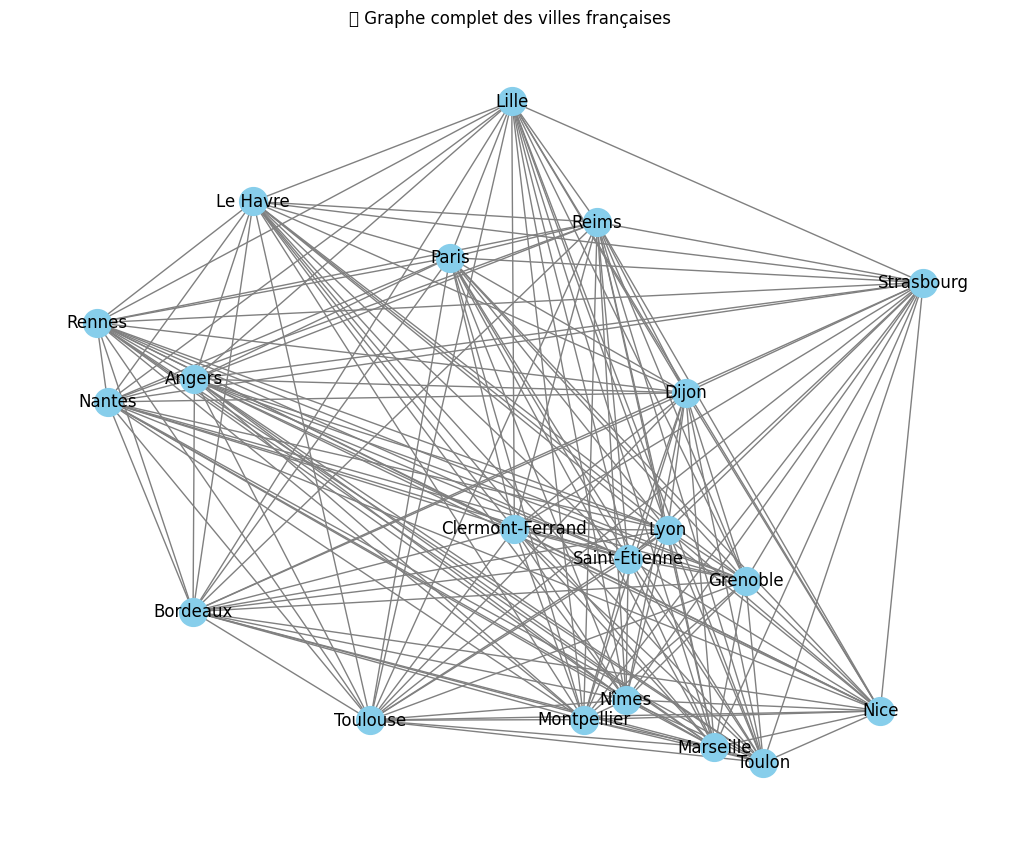

In [5]:
# Visualisation
plt.figure(figsize=(10, 8))
nx.draw(G, pos, node_size=400, node_color='skyblue', edge_color='gray', with_labels=True)
plt.title("🌍 Graphe complet des villes françaises")
plt.show()


/Users/sulivanmoreau/travelling-merchant/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


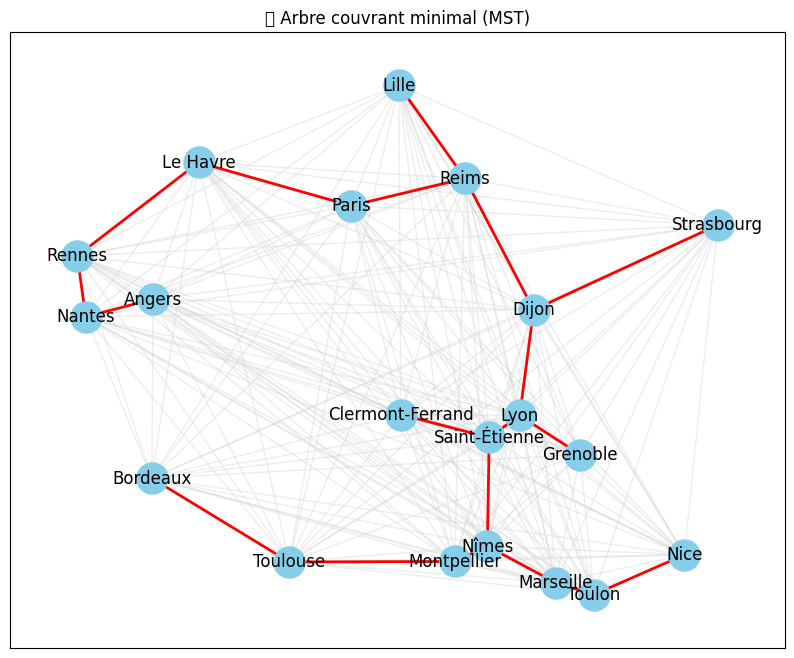

In [6]:

#Calcul du MST

T = nx.minimum_spanning_tree(G, weight='weight')

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G, pos, edge_color='lightgray', alpha=0.4)
nx.draw_networkx_edges(T, pos, edge_color='red', width=2)
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=500)
nx.draw_networkx_labels(G, pos)
plt.title("🌳 Arbre couvrant minimal (MST)")
plt.show()


/Users/sulivanmoreau/travelling-merchant/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


Nœuds impairs : ['Lyon', 'Nice', 'Strasbourg', 'Bordeaux', 'Lille', 'Reims', 'Saint-Étienne', 'Grenoble', 'Dijon', 'Angers', 'Nîmes', 'Clermont-Ferrand']


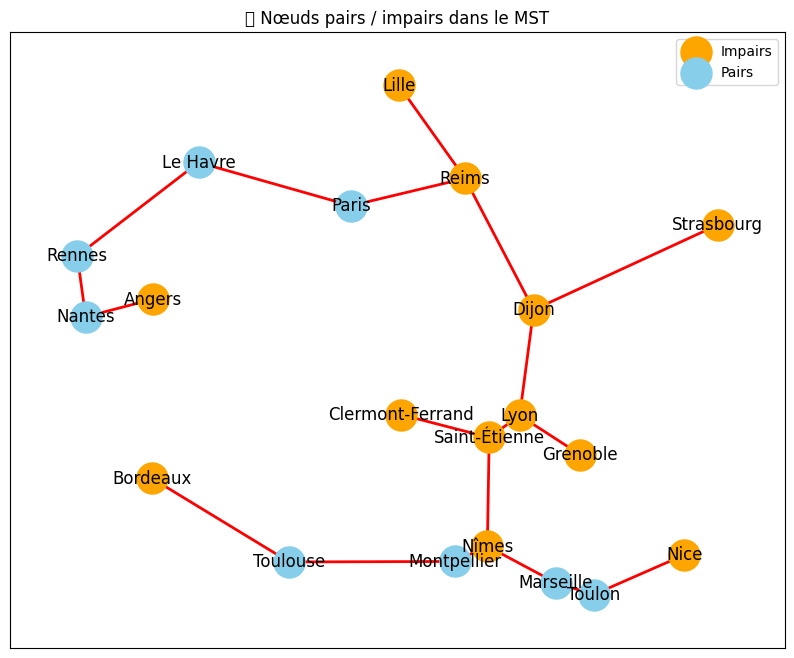

In [7]:
# Identification des nœuds impairs

odd_nodes = [v for v, d in T.degree() if d % 2 == 1]
print("Nœuds impairs :", odd_nodes)

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(T, pos, edge_color='red', width=2)
nx.draw_networkx_nodes(T, pos, nodelist=odd_nodes, node_color='orange', node_size=500, label='Impairs')
nx.draw_networkx_nodes(T, pos, nodelist=[n for n in T if n not in odd_nodes], node_color='skyblue', node_size=500, label='Pairs')
nx.draw_networkx_labels(T, pos)
plt.legend()
plt.title("🟠 Nœuds pairs / impairs dans le MST")
plt.show()


/Users/sulivanmoreau/travelling-merchant/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129510 (\N{SOCKS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


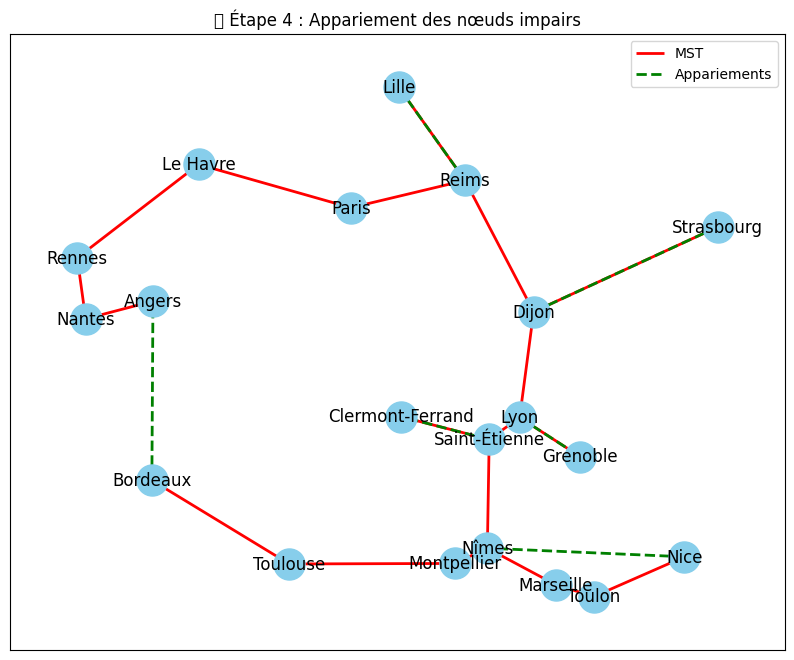

In [8]:

# Appariement parfait de poids minimum
odd_graph = nx.Graph()
for i, u in enumerate(odd_nodes):
    for v in odd_nodes[i+1:]:
        odd_graph.add_edge(u, v, weight=G[u][v]['weight'])

matching = nx.algorithms.matching.min_weight_matching(odd_graph)
matching_edges = [(u, v) for u, v in matching]

T_aug = nx.MultiGraph(T)
T_aug.add_edges_from(matching_edges)

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(T, pos, edge_color='red', width=2, label="MST")
nx.draw_networkx_edges(G, pos, edgelist=matching_edges, edge_color='green', style='dashed', width=2, label="Appariements")
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='skyblue')
nx.draw_networkx_labels(G, pos)
plt.legend()
plt.title("🧦 Étape 4 : Appariement des nœuds impairs")
plt.show()


🚗 Cycle final (Christofides) :
Marseille → Nîmes → Saint-Étienne → Clermont-Ferrand → Lyon → Grenoble → Dijon → Strasbourg → Reims → Lille → Paris → Le Havre → Rennes → Nantes → Angers → Bordeaux → Toulouse → Montpellier → Nice → Toulon → Marseille
Distance totale : 3467.1 km


/Users/sulivanmoreau/travelling-merchant/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


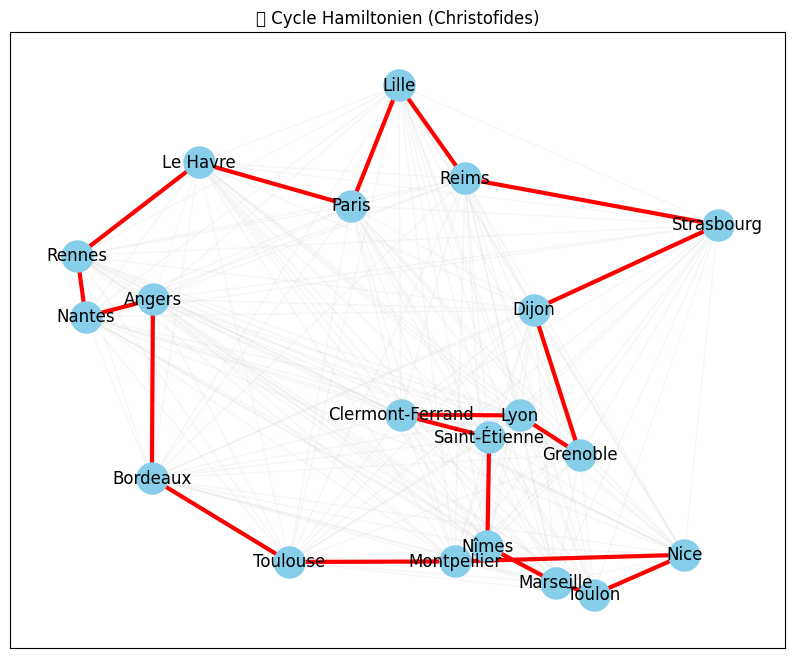

In [9]:
#Construction du cycle hamiltonien (Christofides)

start = "Marseille"
euler_edges = list(nx.eulerian_circuit(T_aug, source=start))
tour = [start]
seen = {start}
for u, v in euler_edges:
    if v not in seen:
        tour.append(v)
        seen.add(v)
tour.append(start)

total_distance = sum(G[tour[i]][tour[i+1]]['weight'] for i in range(len(tour)-1))

print("\n🚗 Cycle final (Christofides) :")
print(" → ".join(tour))
print(f"Distance totale : {total_distance:.1f} km")

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G, pos, edge_color='lightgray', alpha=0.2)
nx.draw_networkx_edges(G, pos, edgelist=list(zip(tour[:-1], tour[1:])), edge_color='red', width=3)
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=500)
nx.draw_networkx_labels(G, pos)
plt.title("🚗 Cycle Hamiltonien (Christofides)")
plt.show()


/var/folders/s5/bjr8wb2s53z275k32l1crzqw0000gn/T/ipykernel_77238/1874002631.py:31: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/sulivanmoreau/travelling-merchant/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


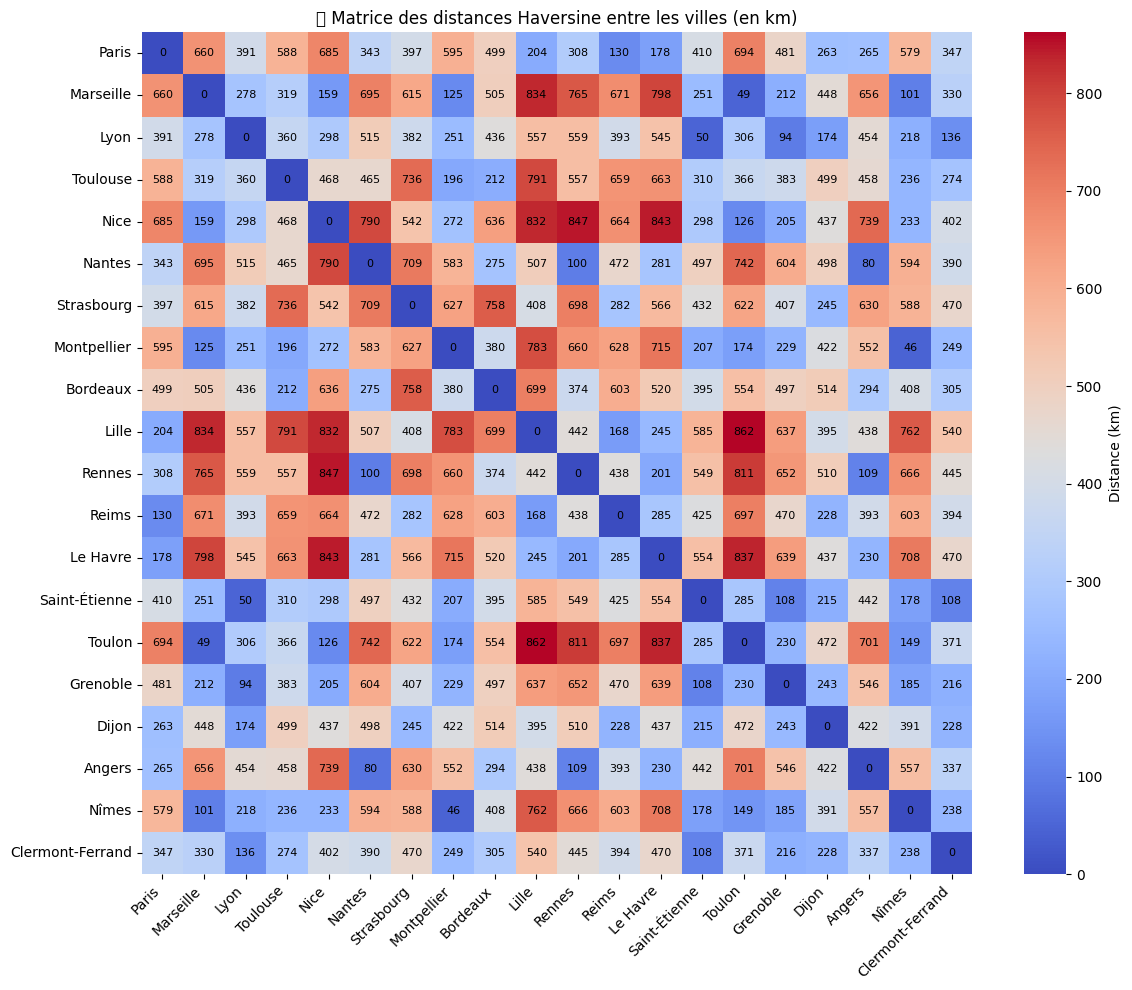

In [10]:

# Matrice des distances Haversine

import seaborn as sns

# Création d'une matrice des distances entre toutes les villes
villes = list(G.nodes())
matrice = pd.DataFrame(index=villes, columns=villes)

for i in villes:
    for j in villes:
        if i == j:
            matrice.loc[i, j] = 0
        else:
            matrice.loc[i, j] = G[i][j]['weight']

matrice = matrice.astype(float)

# Affichage de la heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    matrice,
    cmap="coolwarm",
    annot=True,          # ✅ affiche les valeurs
    fmt=".0f",           # ✅ arrondi sans décimales
    annot_kws={"size": 8, "color": "black"},
    cbar_kws={"label": "Distance (km)"}
)
plt.title("🌍 Matrice des distances Haversine entre les villes (en km)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
